In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import *
import scipy
import h5py
from scipy.fft import *
from nbodykit.lab import *

In [2]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
param_path="/home/x-abairagi/ltu-cmass/params/latin_hypercube_params.txt"

In [25]:
np.loadtxt(param_path)

array([[0.1755 , 0.06681, 0.7737 , 0.8849 , 0.6641 ],
       [0.2139 , 0.05557, 0.8599 , 0.9785 , 0.8619 ],
       [0.1867 , 0.04503, 0.6189 , 0.8307 , 0.7187 ],
       ...,
       [0.2911 , 0.0419 , 0.5102 , 0.8431 , 0.8327 ],
       [0.3256 , 0.0405 , 0.8824 , 0.9073 , 0.8804 ],
       [0.3874 , 0.0507 , 0.5905 , 0.845  , 0.6515 ]])

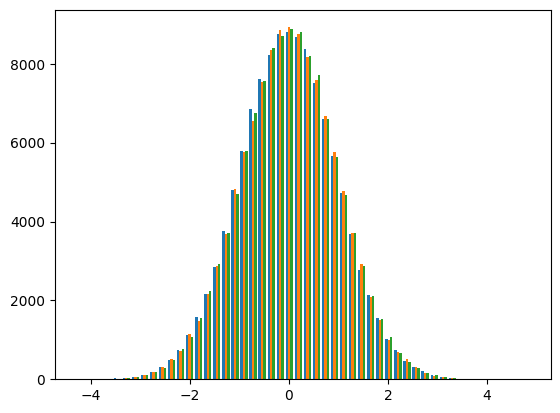

In [147]:
plt.hist(0.125*voxel_size*np.random.randn(*pos.shape),50);

In [2]:
lhid=663
grid = 128
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2
mass=h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['mass'][()].astype('float32')
mass=10**mass
pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)/4
# pos=high_res_pos(pos, n=2)
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# Mass-weighted field
delta_mass=get_delta(pos=pos, grid=grid, W=1, mass=mass, BoxSize=1000.0, MAS=MAS, verbose=True)
k_m, Pk0_m, _, _ = compute_Pk(delta_mass, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)
# Cross-Spectrum
k_X, Pk0_X, _, _ = compute_XPk(delta_mass, delta, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk = Pk0_X/np.sqrt(Pk0*Pk0_m)

pos_target = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
# pos_target=high_res_pos(pos_target, n=2)
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.012 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.10 seconds

Using CIC mass assignment scheme with weights
Time taken = 0.010 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.10 seconds

Computing power spectra of the fields...
Time FFTS = 0.05
Time loop = 0.05
Time taken = 0.09 seconds

Using CIC mass assignment scheme
Time taken = 0.010 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


In [3]:
ind=50
k=k[:ind]
Pk0=Pk0[:ind]
Pk0_m=Pk0_m[:ind]
k_target=k_target[:ind]
Pk0_target=Pk0_target[:ind]
rk=rk[:63]

In [13]:
# Pk0_=Pk0

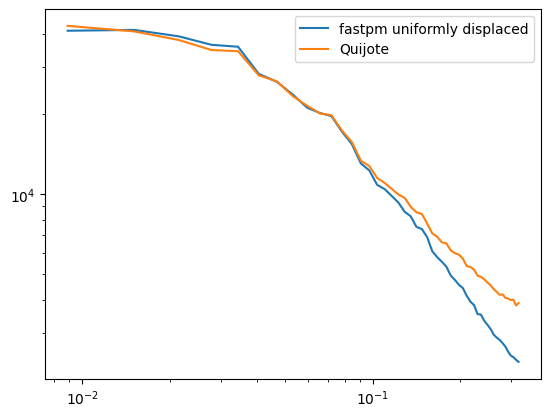

In [4]:
# plt.plot(k_m, Pk0_, label='fastpm')
plt.plot(k, Pk0, label='fastpm uniformly displaced')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.loglog()
plt.legend()
# plt.ylim([1e2, 1e5])

Text(0, 0.5, '$r(k)$')

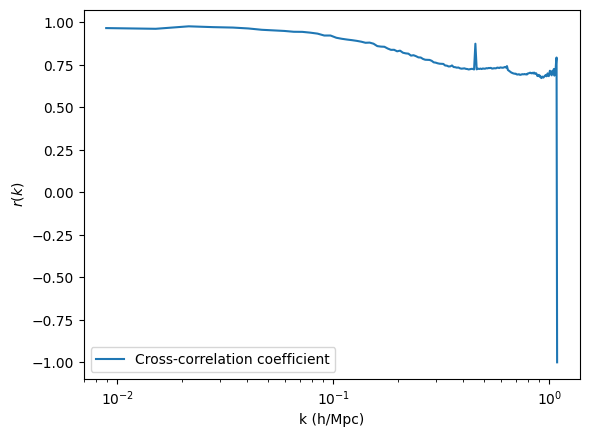

In [5]:
# plt.plot(k, Pk0, label='fastpm number density')
# plt.plot(k, Pk0_m-Pk0, label='fastpm mass-weighted')
# plt.plot(k, Pk0_X-Pk0, label='fastpm cross P(k)')
plt.plot(k, rk, label='Cross-correlation coefficient')
plt.semilogx()
plt.legend()
plt.xlabel("k (h/Mpc)")
plt.ylabel("$r(k)$")

In [17]:
# Pk0=Pk0_corrected
Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize)
Qk=np.abs(Qk)
# Qk[Qk<0]=0
phi = get_phi(k, Qk, grid=grid, BoxSize=BoxSize, Rayleigh_sampling=0)
a_x, a_y, a_z = calculate_acc(phi, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta(k) field generated
time taken = 0.12093 seconds



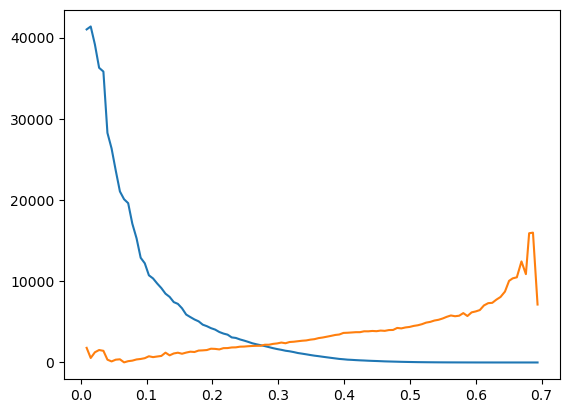

In [18]:
plt.plot(k,Pk0, label='fastpm')
plt.plot(k,k**4*Qk, label='Q(k)')

In [19]:
delta_corrected=get_delta(pos=pos_corrected, grid=128, W=0, mass=1, BoxSize=1000., MAS='CIC', verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=1000., MAS='CIC', axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.009 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.08 seconds


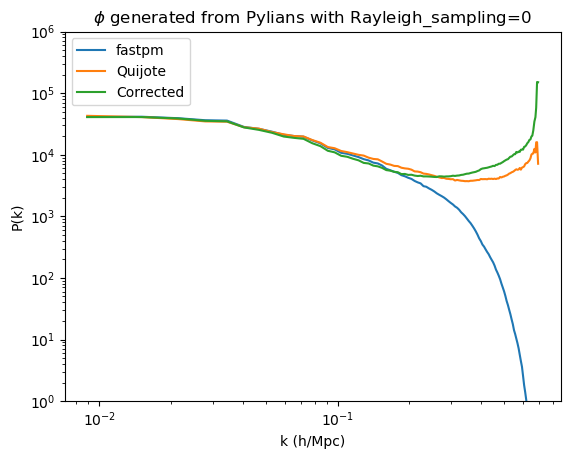

In [20]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\phi$ generated from Pylians with Rayleigh_sampling=0")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,1000000])
plt.legend()

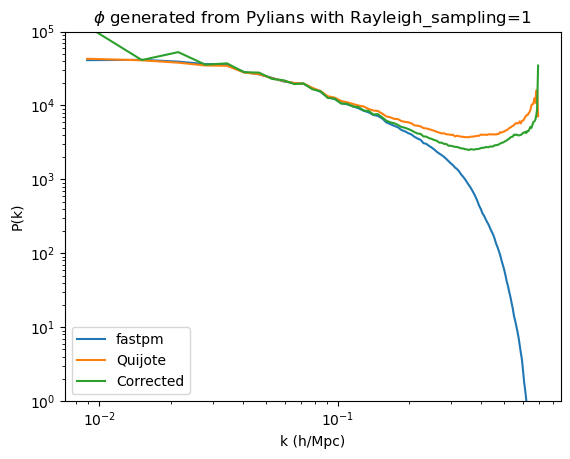

In [40]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\phi$ generated from Pylians with Rayleigh_sampling=1")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,100000])
plt.legend()


In [48]:
def get_iterative_perturb_pos(k, Pk0, Pk0_target, grid=128, BoxSize=1000., iteration=3):
    for it in range(iteration):
        Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize)
        Qk=np.abs(Qk)
        # Qk[Qk<0]=0
        phi = get_phi(k, Qk, grid=grid, BoxSize=BoxSize)
        a_x, a_y, a_z = calculate_acc(phi, grid=grid, BoxSize=BoxSize)
        pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)
        
        delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS='CIC', verbose=True)
        k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS='CIC', axis=0, verbose=True)
        plt.loglog(k_corrected, Pk0_corrected, label=f'Corrected-{it}')
        k, Pk0 = k_corrected, Pk0_corrected
    plt.show()
    plt.legend()
    

In [81]:
# get_iterative_perturb_pos(k, Pk0, Pk0_target, grid=128, BoxSize=1000., iteration=2)
# np.zeros(3*[128]).shape

In [72]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta_k = fftshift(fftn(delta))
MAS_index=2
rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
binlist = np.linspace(rad.min(), rad.max(), len(k))
index = np.digitize(rad, binlist)-1

Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize).astype(np.complex64)
# Qk=np.abs(Qk)
# Qk[Qk<0]=0
weights = np.sqrt(Qk/Pk0)
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
# f=1
# (grid/BoxSize)**1*(2*np.pi)
# a_x, a_y, a_z = f*a_x, f*a_y, f*a_z
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

In [74]:
delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.009 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.07 seconds


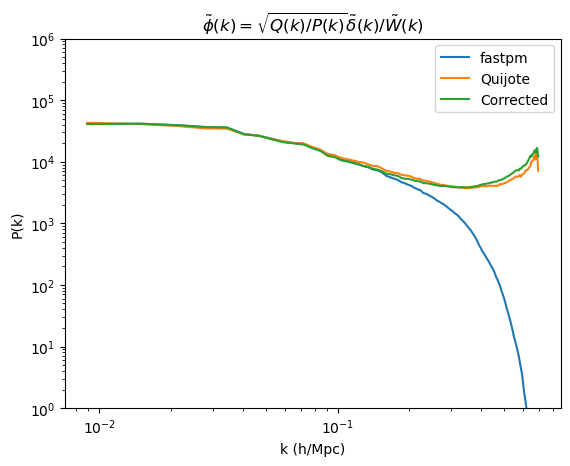

In [75]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\\tilde{\phi}(k)=\sqrt{Q(k)/P(k)}\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,1e6])
plt.legend()

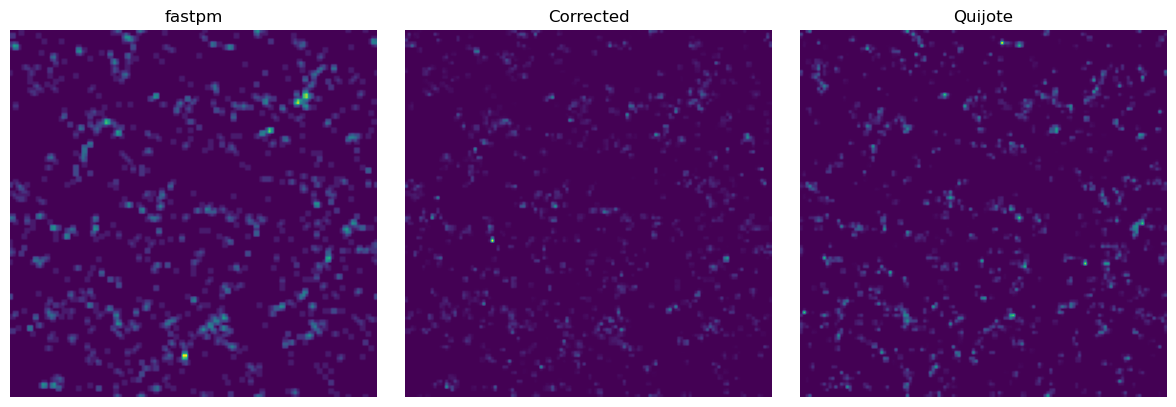

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# plt.imshow(delta[0])
ind=50
axes[0].imshow(delta[ind])
axes[0].set_title("fastpm")

axes[1].imshow(delta_corrected[ind])
axes[1].set_title("Corrected")

axes[2].imshow(delta_target[ind])
axes[2].set_title("Quijote")

for ax in axes:
    ax.axis("off")

plt.tight_layout()  # Adjust layout
plt.show()


In [42]:
Bk, Qk = compute_Bk(delta, grid, BoxSize, MAS='CIC', threads=1)

In [43]:
Bk_target, Qk_target = compute_Bk(delta_target, grid, BoxSize, MAS='CIC', threads=1)

In [44]:
Bk_corrected, Qk_corrected = compute_Bk(delta_corrected, grid, BoxSize, MAS='CIC', threads=1)

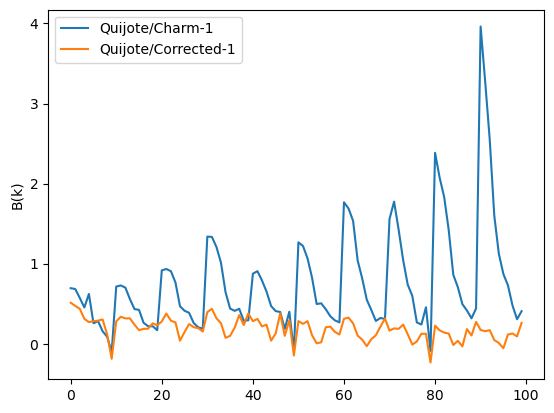

In [45]:
plt.plot(Bk_target[450:]/Bk[450:]-1, label="Quijote/Charm-1")
plt.plot(Bk_target[450:]/Bk_corrected[450:]-1, label="Quijote/Corrected-1")
plt.ylabel("B(k)")
# plt.xlim([200,500])
# plt.loglog()
plt.legend()

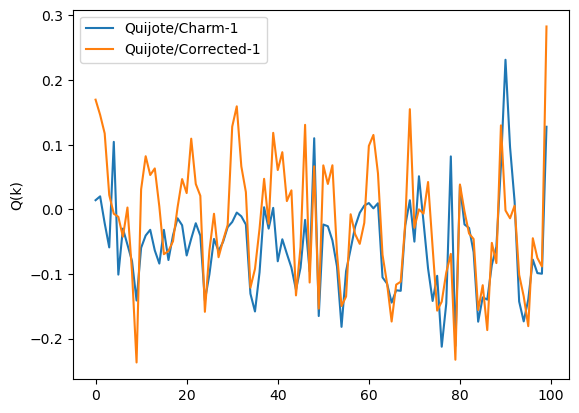

In [46]:
plt.plot(Qk_target[450:]/Qk[450:]-1, label="Quijote/Charm-1")
plt.plot(Qk_target[450:]/Qk_corrected[450:]-1, label="Quijote/Corrected-1")
plt.ylabel("Q(k)")
# plt.xlim([200,500])
# plt.loglog()
plt.legend()

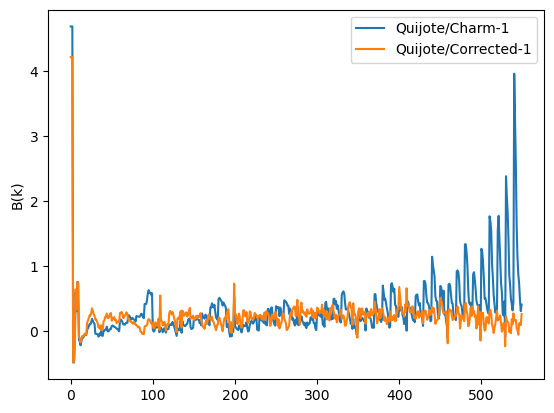

In [47]:
plt.plot(Bk_target/Bk-1, label="Quijote/Charm-1")
plt.plot(Bk_target/Bk_corrected-1, label="Quijote/Corrected-1")
plt.ylabel("B(k)")
plt.legend()

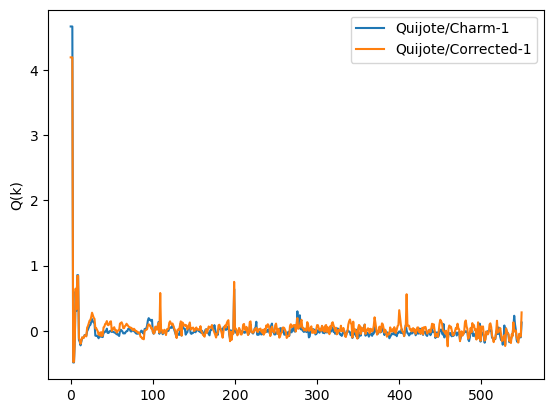

In [48]:
plt.plot(Qk_target/Qk-1, label="Quijote/Charm-1")
plt.plot(Qk_target/Qk_corrected-1, label="Quijote/Corrected-1")
plt.ylabel("Q(k)")
plt.legend()

In [43]:
I=np.zeros([len(k), len(k)])
dz=1e-5
z=np.arange(-1,1+dz,dz)
for i,ki in enumerate(k):
    for j,qj in enumerate(k):

        k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)
        Pk_nl=np.interp(k_in, k, Pk0)
        if ki==qj:
            Pk_nl[-1]=0

        I[i,j]=8*np.pi**2*ki**2*qj**2*np.trapz(Pk_nl*z**2,z)

I2=np.identity(len(k))
for i, ki in enumerate(k):
    I2[i,i]*=ki**4

V=BoxSize**3
A=(I/V+I2)
# A=I2
a=np.matmul(A,Pk0)
# a=np.matmul(A,Pk0_m)


I3=np.identity(len(k))
for i, ki in enumerate(k):
    I3[i,i]*=2*ki**2
b=np.matmul(I3,Pk0*rk)
# b=np.matmul(I3,Pk0_X)

I4=np.zeros([len(k), len(k)])
dz=1e-4
z=np.arange(-1,1+dz,dz)
for i,ki in enumerate(k):
    for j,qj in enumerate(k):

        I4[i,j]=(16/3)*np.pi**2*ki**4*qj**2*Pk0[i]

d=np.matmul(I4,Pk0)

c=Pk0-Pk0_target

# Qk=np.matmul(np.linalg.inv(A),B)

In [39]:
k_in[25:60000], k

(array([0.00709318, 0.00723366, 0.00737145, ..., 0.34748493, 0.34748782,
        0.34749072]),
 array([0.00889964, 0.01507912, 0.0214479 , 0.02783661, 0.034351  ,
        0.04047887, 0.04676717, 0.05308225, 0.05945362, 0.06576225,
        0.07196633, 0.07827861, 0.08470399, 0.09096855, 0.0972079 ,
        0.1034763 , 0.10975764, 0.11605431, 0.12236697, 0.12868173,
        0.13495008, 0.14119496, 0.14751336, 0.15378651, 0.16006575,
        0.16639912, 0.17271956, 0.17897652, 0.18523537, 0.19148068,
        0.19778899, 0.20409377, 0.21039393, 0.21669097, 0.22297003,
        0.229262  , 0.23551415, 0.24179106, 0.24808565, 0.25434923,
        0.26063343, 0.26692574, 0.27324233, 0.27955297, 0.28583663,
        0.29208763, 0.29834498, 0.30463826, 0.31092791, 0.31721682]))

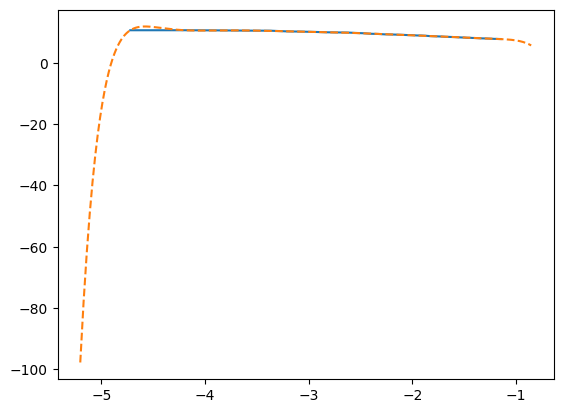

In [64]:
plt.plot(np.log(k), np.log(Pk0),'-')
plt.plot(np.log(k_in[15:90000]), np.poly1d(np.polyfit(np.log(k), np.log(Pk0),10))(np.log(k_in[15:90000])), '--')

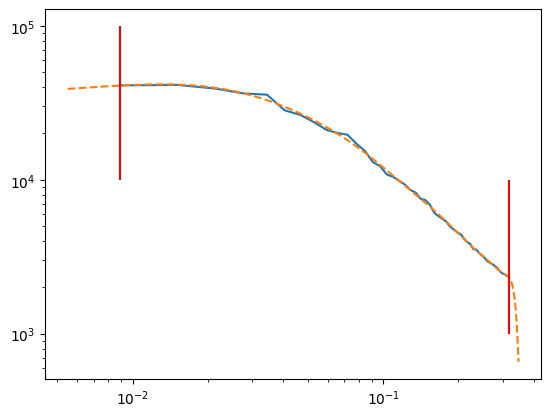

In [41]:
plt.loglog(k, np.exp(np.log(Pk0)),'-')
plt.loglog(k_in[15:60000], np.exp(np.poly1d(np.polyfit(k, np.log(Pk0),10))(k_in[15:60000])), '--')
plt.vlines(k[0], ymin=1e4, ymax=1e5, color='r')
plt.vlines(k[-1], ymin=1e3, ymax=1e4, color='r')

In [6]:
I=np.zeros([len(k), len(k)])
dz=1e-5
z=np.arange(-1,1+dz,dz)
for i,ki in enumerate(k):
    for j,qj in enumerate(k):

        k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)
        Pk_nl=np.interp(k_in, k, Pk0)
        if ki==qj:
            Pk_nl[-1]=0

        I[i,j]=8*np.pi**2*ki**2*qj**2*np.trapz(Pk_nl*z**2,z)

I2=np.identity(len(k))
for i, ki in enumerate(k):
    I2[i,i]*=ki**4

V=BoxSize**3
A=(I/V+I2)
# A=I2
a=np.matmul(A,Pk0)


I3=np.identity(len(k))
for i, ki in enumerate(k):
    I3[i,i]*=2*ki**2
b=np.matmul(I3,Pk0)


c=Pk0-Pk0_target


In [7]:
coeffs=np.column_stack([a,b,c])
roots=np.array([np.roots(coeffs[i]) for i in range(len(k))])

In [20]:
a0=roots[:,1].real  #central halos

In [35]:
a1=roots[:,1].real  #uniformly displaced

In [46]:
a2=roots[:,1].real  #uniformly displaced overdensity

In [76]:
a3=roots[:,1].real  #uniformly displaced 50

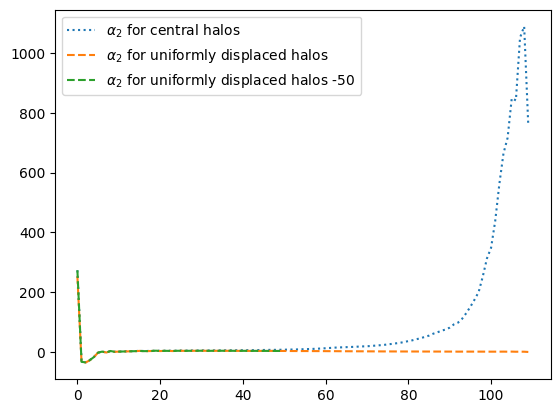

In [78]:
plt.plot(a0, ':', label='$\\alpha_2$ for central halos')
plt.plot(a1, '--', label='$\\alpha_2$ for uniformly displaced halos')
plt.plot(a3, '--', label='$\\alpha_2$ for uniformly displaced halos -50')
# plt.plot(a2, '--', label='$\\alpha_2$ for uniformly displaced halos - overdensity')
# plt.loglog()
plt.legend()

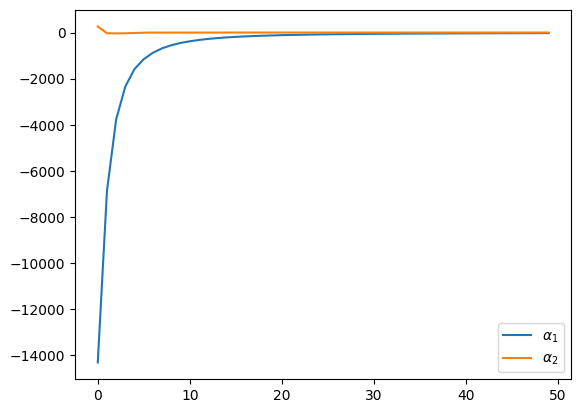

In [8]:
plt.plot(roots[:,0].real, label='$\\alpha_1$')
plt.plot(roots[:,1].real, label='$\\alpha_2$')
# plt.loglog()
plt.legend()

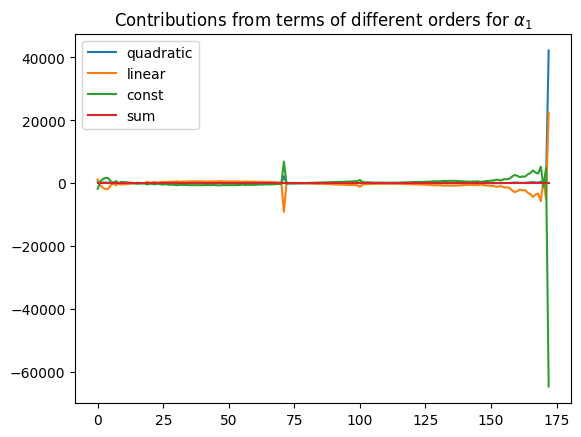

In [10]:
alpha=roots[:,1].real
plt.plot(alpha**2*a, label='quadratic')
plt.plot(alpha*b, label='linear')
plt.plot(c, label='const')
plt.plot(quadratic_eq(a,b,c,alpha), label='sum')
# plt.plot(alpha, label="alpha")
plt.title("Contributions from terms of different orders for $\\alpha_1$")
plt.legend()

In [9]:
def quadratic_eq(a,b,c, alpha):
    return (alpha**2*a+alpha*b+c)
quadratic_eq(a,b,c,roots[:,0].real)

array([-1.36424205e-12,  0.00000000e+00,  1.81898940e-12,  0.00000000e+00,
        0.00000000e+00, -3.63797881e-12,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.63797881e-12,  0.00000000e+00,
       -1.81898940e-12, -1.81898940e-12,  1.81898940e-12,  0.00000000e+00,
       -3.63797881e-12,  0.00000000e+00, -5.45696821e-12, -3.63797881e-12,
        3.63797881e-12,  1.81898940e-12,  5.45696821e-12,  9.09494702e-13,
        0.00000000e+00, -9.09494702e-13,  9.09494702e-13, -2.72848411e-12,
       -1.81898940e-12, -9.09494702e-13, -3.63797881e-12,  1.81898940e-12,
        9.09494702e-13, -1.81898940e-12,  9.09494702e-13,  0.00000000e+00,
        0.00000000e+00, -2.72848411e-12,  1.36424205e-12, -9.09494702e-13,
        1.81898940e-12,  1.81898940e-12,  1.81898940e-12,  4.54747351e-13,
        9.09494702e-13, -2.72848411e-12,  4.54747351e-13, -1.36424205e-12,
        4.54747351e-13,  4.54747351e-13, -4.54747351e-13,  4.54747351e-13,
        9.09494702e-13,  

In [22]:
alpha=roots[:,0].real
# .reshape(len(k),-1)

In [92]:
discriminator = np.sqrt(b**2-4*a*c)
alpha1 = (-b+discriminator)/(2*a)
alpha2 = (-b-discriminator)/(2*a)

In [109]:
np.concatenate([roots[:,1],np.zeros(47)])

array([ 2.72574432e+02, -3.91397932e+01, -4.21145967e+01, -3.14005320e+01,
       -1.96794613e+01, -6.61812179e+00, -2.18546125e+00, -4.32718645e+00,
        8.25999792e-01, -2.26978287e+00, -1.27175464e+00, -1.25981267e+00,
       -1.03356856e+00, -6.93030174e-01, -7.31986021e-01,  7.08052915e-01,
        2.40127527e-01,  1.09174847e-01,  3.19758559e-01,  1.50907588e+00,
        4.89815019e-01,  1.01676430e+00,  1.26617071e+00,  6.50340460e-01,
        1.21014439e+00,  1.47711231e+00,  1.12544915e+00,  1.60755718e+00,
        1.56057458e+00,  1.50164410e+00,  1.88469822e+00,  1.75126191e+00,
        1.57233900e+00,  1.65025295e+00,  1.62777148e+00,  1.94149687e+00,
        1.83133703e+00,  1.73580571e+00,  1.57901477e+00,  1.87372991e+00,
        1.83582345e+00,  1.76952606e+00,  1.51787407e+00,  1.56693715e+00,
        1.53799352e+00,  1.78501308e+00,  1.70057247e+00,  1.67291470e+00,
        1.58809311e+00,  1.49564380e+00,  1.43021228e+00,  1.57182315e+00,
        1.53880011e+00,  

In [48]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta_k = fftshift(fftn(delta_mass))

rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
            
binlist = np.linspace(rad.min(), rad.max(), 110)
index = np.digitize(rad, binlist)-1

# weights = roots[:,1].real*np.sqrt(Pk0/Pk0_m)
weights = np.concatenate([roots[:,1],np.zeros(47)])*np.sqrt(np.concatenate([Pk0,np.zeros(47)])/np.concatenate([Pk0_m,np.ones(47)]))
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.009 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


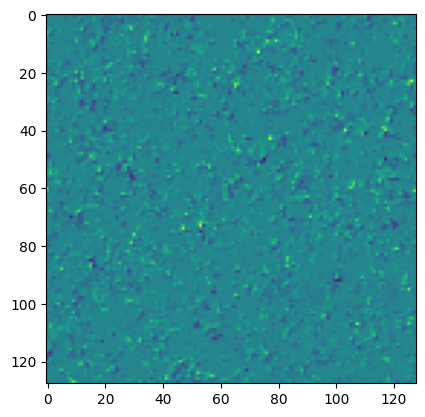

In [207]:
plt.imshow((delta_target-delta)[0])

In [38]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta_k = fftshift(fftn(delta))

rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
            
binlist = np.linspace(rad.min(), rad.max(), 110)
index = np.digitize(rad, binlist)-1

weights = roots[:,1].real
# weights = np.concatenate([roots[:,1].real,np.zeros(47)])
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.009 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


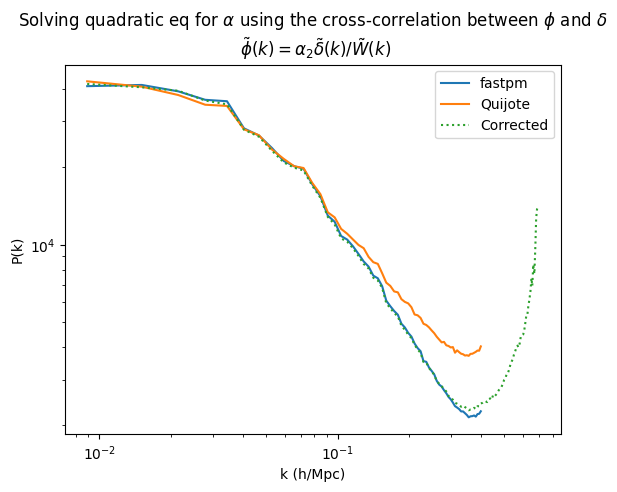

In [49]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, ls=':', label='Corrected')
plt.loglog()
# plt.title("$\\tilde{\phi}(k)=\sqrt{Q(k)/P(k)}\\tilde{\delta}(k)$")
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
# plt.ylim([1,100000])
plt.legend()

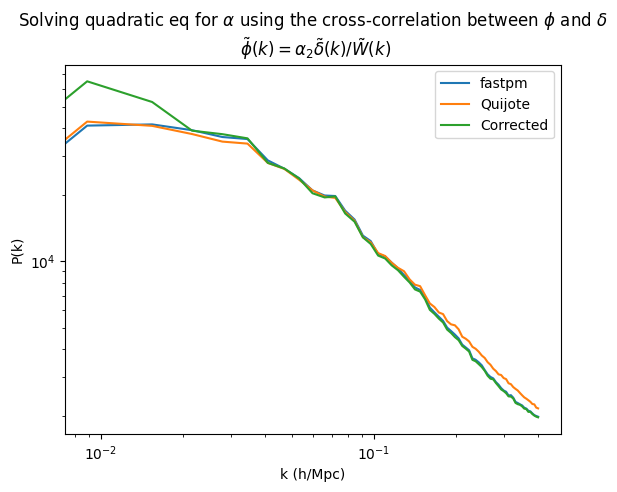

In [137]:
compensated=True
interlaced=True
MAS='cic'
delta=get_delta_nbodykit(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta, mode='1d')
Pk0 = r.power

delta_target=get_delta_nbodykit(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=True)
r = FFTPower(delta_target, mode='1d')
Pk0_target = r.power

delta_corrected=get_delta_nbodykit(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta_corrected, mode='1d')
Pk0_corrected = r.power

plt.plot(Pk0['k'], Pk0['power'].real, label='fastpm')
plt.plot(Pk0_target['k'], Pk0_target['power'].real, label='Quijote')
plt.plot(Pk0_corrected['k'], Pk0_corrected['power'].real, label='Corrected')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
# plt.ylim([1,100000])
plt.legend()

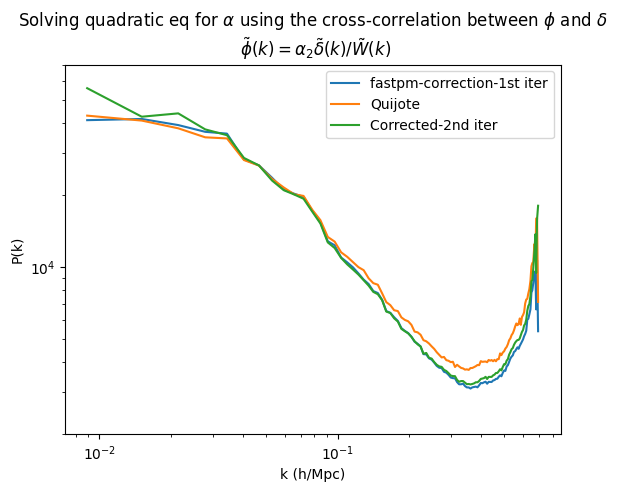

In [21]:
plt.plot(k, Pk0, label='fastpm-correction-1st iter')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected-2nd iter')
plt.loglog()
# plt.title("$\\tilde{\phi}(k)=\sqrt{Q(k)/P(k)}\\tilde{\delta}(k)$")
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([2e3,7e4])
plt.legend()

In [138]:
k_QuiXFPM, Pk0_QuiXFPM, _, _ = compute_XPk(delta_target, delta, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk_QuiXFPM = Pk0_QuiXFPM/np.sqrt(Pk0_target*Pk0)

k_QuiXcorrected, Pk0_QuiXcorrected, _, _ = compute_XPk(delta_target, delta_corrected, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk_QuiXcorrected = Pk0_QuiXcorrected/np.sqrt(Pk0_target*Pk0_corrected)


Computing power spectra of the fields...


TypeError: object of type 'RealField' has no len()

Text(0, 0.5, 'Cross Correlation Coefficient $r(k)$')

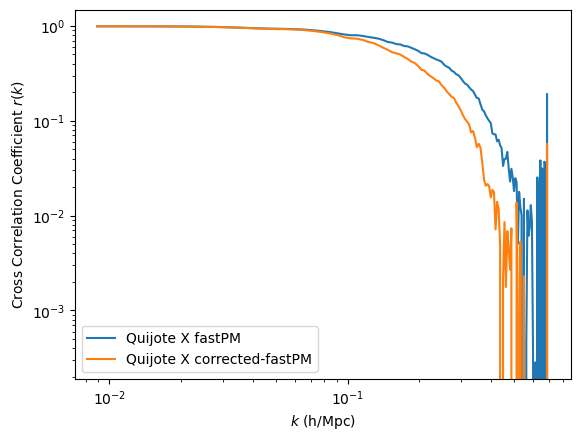

In [40]:
plt.plot(k_QuiXFPM, rk_QuiXFPM, label="Quijote X fastPM")
plt.plot(k_QuiXcorrected, rk_QuiXcorrected, label="Quijote X corrected-fastPM")
plt.loglog()
plt.legend()
plt.xlabel("$k$ (h/Mpc)")
plt.ylabel("Cross Correlation Coefficient $r(k)$")

In [47]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta_k = fftshift(fftn(delta))

rad = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            
binlist = np.linspace(rad.min(), rad.max(), len(k))
index = np.digitize(rad, binlist)-1

Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize).astype(np.complex64)
neg_ind=np.where(Qk<0)[0]
Qk=np.abs(Qk)
# Qk[Qk<0]=0
# weights = np.sqrt(Qk/Pk0)
phi = get_phi(k, Qk, grid=grid, BoxSize=BoxSize, Rayleigh_sampling=0)
weights = np.ones_like(Qk, dtype=complex)
weights[neg_ind]=1j
phi_k = weights[index]*fftshift(fftn(phi))

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta(k) field generated
time taken = 0.12098 seconds



In [38]:
weights = np.ones_like(Qk)
neg_ind=np.where(Qk<0)[0]
weights[neg_ind]=1j
phi_k = weights[index]*fftshift(fftn(phi))

In [49]:
delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS='CIC', verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS='CIC', axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.010 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.08 seconds


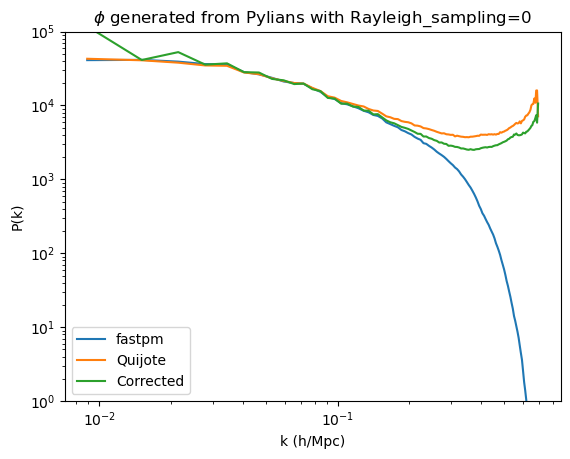

In [50]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\phi$ generated from Pylians with Rayleigh_sampling=0")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,100000])
plt.legend()

In [18]:
pos*128/1000.

array([[  0.5,   0.5,   6.5],
       [  0.5,   0.5,  76.5],
       [  0.5,   0.5, 116.5],
       ...,
       [127.5, 127.5,  28.5],
       [127.5, 127.5,  45.5],
       [127.5, 127.5,  87.5]], dtype=float32)

In [19]:
-0.5%128

127.5

In [13]:
pos.max()*128/1000.

127.5